In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
train_df = pd.read_csv("Titanic_train.csv")
test_df=pd.read_csv('Titanic_test.csv')
print(train_df.head())
print(test_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [3]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (891, 12)
Test Shape: (418, 11)


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train_df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### The histogram analysis shows that the Fare feature is positively skewed and contains outliers. 
###  The pair plot indicates that passengers with higher fares had greater survival probability. 
### The heatmap reveals that Pclass and Fare are correlated with survival.

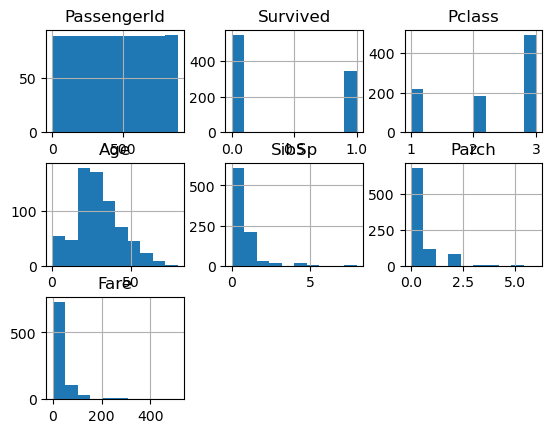

In [7]:
train_df.hist()
plt.show()

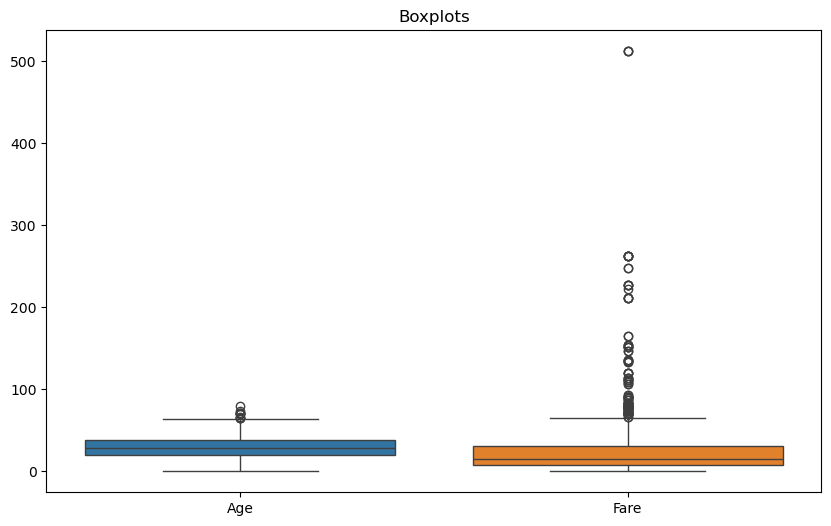

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=train_df[['Age','Fare']]
)

plt.title("Boxplots")

plt.show()

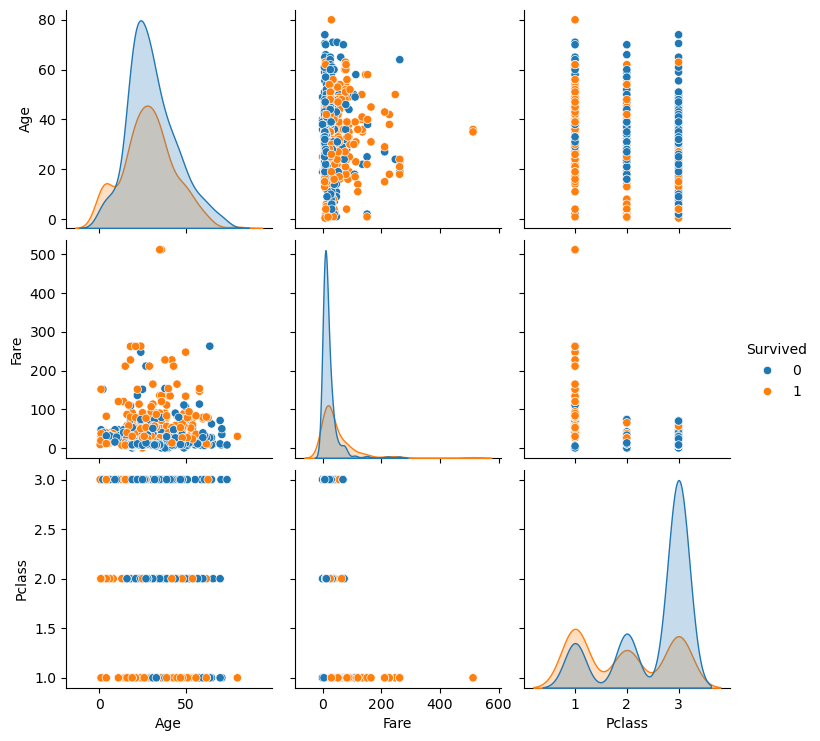

In [9]:
sns.pairplot(
    train_df[
        ['Age','Fare','Pclass','Survived']
    ],
    hue='Survived'
)

plt.show()

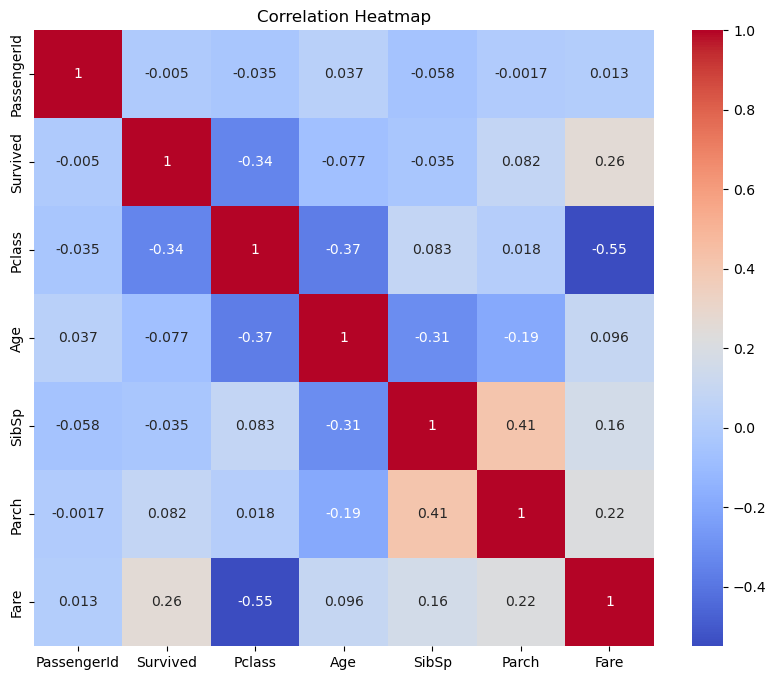

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    train_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Missing values in the Age column were handled using median imputation to avoid data loss. 
### Categorical variables such as Sex and Embarked were encoded into numerical values because machine learning models require numeric input.

In [11]:
imputer = SimpleImputer(strategy='median')

train_df['Age'] = imputer.fit_transform(
    train_df[['Age']]
)

test_df['Age'] = imputer.transform(
    test_df[['Age']]
)

train_df['Embarked'] = train_df['Embarked'].fillna(
    train_df['Embarked'].mode()[0]
)

test_df['Embarked'] = test_df['Embarked'].fillna(
    train_df['Embarked'].mode()[0]
)

In [12]:
le = LabelEncoder()

train_df['Sex'] = le.fit_transform(
    train_df['Sex']
)

test_df['Sex'] = le.transform(
    test_df['Sex']
)

train_df['Embarked'] = le.fit_transform(
    train_df['Embarked']
)

test_df['Embarked'] = le.transform(
    test_df['Embarked']
)

In [13]:
drop_cols = [
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin'
]

train_df.drop(
    drop_cols,
    axis=1,
    inplace=True
)


In [14]:
X = train_df.drop(
    'Survived',
    axis=1
)

y = train_df['Survived']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8044692737430168
Precision: 0.782608695652174
Recall: 0.7297297297297297
F1 Score: 0.7552447552447552
ROC AUC: 0.8818532818532818


#### The model achieved good classification performance based on accuracy, precision, recall, and F1-score. 
#### The ROC-AUC score indicates the model's ability to distinguish between survived and non-survived passengers.

In [19]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coeff_df)

    Feature  Coefficient
0    Pclass    -0.782061
1       Sex    -1.278865
2       Age    -0.395574
3     SibSp    -0.349582
4     Parch    -0.098292
5      Fare     0.126216
6  Embarked    -0.170860


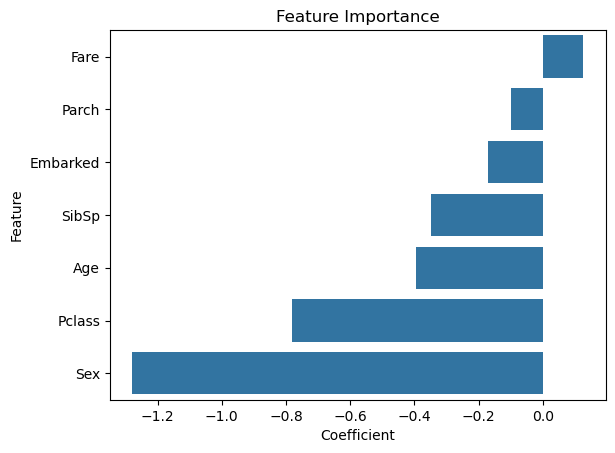

In [20]:
coeff_df = coeff_df.sort_values(
    by='Coefficient',
    ascending=False
)

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coeff_df
)

plt.title("Feature Importance")
plt.show()

#### Positive coefficients increase the probability of survival, while negative coefficients reduce survival probability. 
#### Features such as Fare positively influence survival, whereas higher passenger class numbers negatively affect survival. 
#### This indicates that passengers who paid higher fares had a greater chance of survival, while lower-class passengers had reduced survival probability.

In [ ]:
!streamlit run app.py

# 1. What is the difference between Precision and Recall?

"""
Precision measures how many predicted positive cases are actually positive.

Precision = TP / (TP + FP)

Recall measures how many actual positive cases are correctly identified by the model.

Recall = TP / (TP + FN)

Precision focuses on reducing false positives, while recall focuses on reducing false negatives.
"""

# 2. What is Cross-Validation and Why is it Important in Binary Classification?

"""
Cross-validation is a technique used to evaluate machine learning models by dividing the dataset into multiple subsets.

In K-Fold Cross Validation:
1. The dataset is divided into K equal parts.
2. The model is trained on K−1 folds.
3. The remaining fold is used for testing.
4. The process repeats K times.

Cross-validation is important because:
- it provides reliable model evaluation,
- reduces overfitting,
- improves model generalization,
- and ensures consistent performance on unseen data.
"""